In [11]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.preprocessing import label_binarize
import time
from PIL import Image

In [12]:

device = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available()
                      else "cpu")
print(f"Using device: {device}")


Using device: mps


In [13]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Convert to grayscale if needed
    transforms.Resize((28, 28)),                   # Ensure 28x28 size
    transforms.ToTensor(),                         # Convert to tensor
    transforms.Normalize((0.5,), (0.5,))          # Normalize to [-1, 1]
])

In [14]:
data_dir = "datasets/cnn_dataset"

In [16]:
# Load full dataset
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
    
print(f"Total samples: {len(full_dataset)}")
print(f"Number of classes: {len(full_dataset.classes)}")
print(f"Classes: {full_dataset.classes[:10]}...")  # Show first 10 classes
    
    # Split into train, validation, and test sets (70:15:15)
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
    
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)
    
print(f"\nDataset splits:")
print(f"  Training: {len(train_dataset)} samples")
print(f"  Validation: {len(val_dataset)} samples")
print(f"  Testing: {len(test_dataset)} samples")
    


Total samples: 100800
Number of classes: 36
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']...

Dataset splits:
  Training: 70560 samples
  Validation: 15120 samples
  Testing: 15120 samples


In [17]:
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


Visualizing sample images...


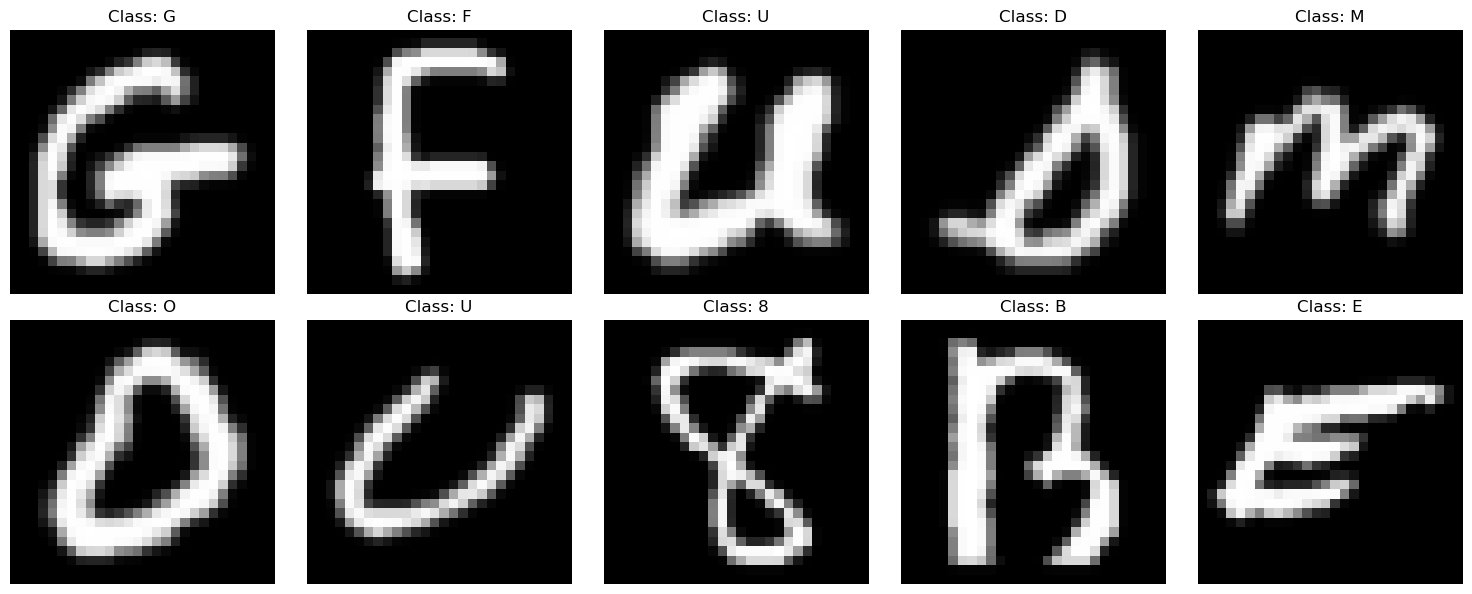

In [18]:
print("\nVisualizing sample images...")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
sample_iter = iter(train_loader)
sample_images, sample_labels = next(sample_iter)

for idx, ax in enumerate(axes.flat):
    img = sample_images[idx].squeeze().numpy()
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Class: {full_dataset.classes[sample_labels[idx]]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

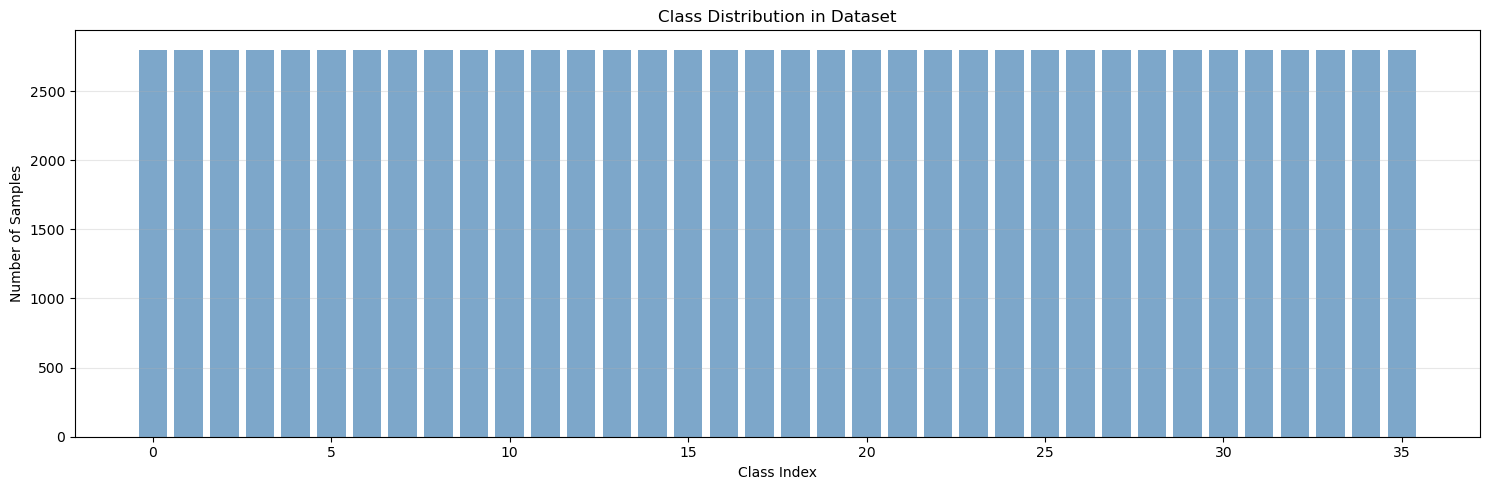

In [19]:
all_labels = [label for _, label in full_dataset]
unique_classes, counts = np.unique(all_labels, return_counts=True)

plt.figure(figsize=(15, 5))
plt.bar(range(len(unique_classes)), counts, color='steelblue', alpha=0.7)
plt.xlabel('Class Index')
plt.ylabel('Number of Samples')
plt.title('Class Distribution in Dataset')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

plt.show()

In [20]:
print(f"\nClass balance:")
print(f"  Min samples per class: {counts.min()}")
print(f"  Max samples per class: {counts.max()}")
print(f"  Average samples per class: {counts.mean():.1f}")


Class balance:
  Min samples per class: 2800
  Max samples per class: 2800
  Average samples per class: 2800.0


In [21]:
class BasicCNN(nn.Module):
    def __init__(self, num_classes=36, dropout=0.3):
        super(BasicCNN, self).__init__()
        
        # Convolutional layers
        self.conv_layers = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 28x28x32
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),  # 28x28x32
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),        # 14x14x32
            nn.Dropout2d(dropout),
            
            # Conv Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 14x14x64
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),  # 14x14x64
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),        # 7x7x64
            nn.Dropout2d(dropout),
            
            # Conv Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 7x7x128
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),        # 3x3x128
            nn.Dropout2d(dropout),
        )
        
        # Fully connected layers
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [22]:
model = BasicCNN(num_classes=len(full_dataset.classes)).to(device)
print(model)

BasicCNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Dropout2d(p=0.3, inplace=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout2d(p=0.3, inplace=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout2d(p=0.3, inplace=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1152, out_features=256, 

In [23]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Total parameters: 471,556
Trainable parameters: 471,556


In [24]:
def train_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Track metrics
        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

def validate_epoch(model, dataloader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            
            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

In [25]:
def train_cnn(model, train_loader, val_loader, loss_fn, optimizer, 
              epochs=50, scheduler=None, device='cpu'):
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'epoch_time': []
    }
    
    best_val_acc = 0.0
    best_model_state = None
    
    for epoch in range(1, epochs + 1):
        start_time = time.time()
        
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, loss_fn, optimizer, device)
        
        # Validate
        val_loss, val_acc = validate_epoch(model, val_loader, loss_fn, device)
        
        # Scheduler step
        if scheduler is not None:
            scheduler.step(val_loss)
        
        epoch_time = time.time() - start_time
        
        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['epoch_time'].append(epoch_time)
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        if epoch % 5 == 0:
            lr = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch:03d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
                  f"LR: {lr:.6f} | Time: {epoch_time:.2f}s")
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
    
    print(f"\nTotal training time: {sum(history['epoch_time']):.2f}s")
    print(f"Best validation accuracy: {best_val_acc:.4f}")
    
    return history


In [26]:
base_cnn = BasicCNN(num_classes=len(full_dataset.classes), dropout=0.3).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(base_cnn.parameters(), lr=0.001)

print("\nTraining base CNN model...")
base_history = train_cnn(base_cnn, train_loader, val_loader, loss_fn, optimizer, 
                         epochs=50, device=device)


Training base CNN model...
Epoch 005/50 | Train Loss: 0.3521 | Train Acc: 0.8778 | Val Loss: 0.2411 | Val Acc: 0.9081 | LR: 0.001000 | Time: 35.95s
Epoch 010/50 | Train Loss: 0.2939 | Train Acc: 0.8932 | Val Loss: 0.2215 | Val Acc: 0.9142 | LR: 0.001000 | Time: 36.26s
Epoch 015/50 | Train Loss: 0.2682 | Train Acc: 0.9001 | Val Loss: 0.2133 | Val Acc: 0.9160 | LR: 0.001000 | Time: 35.90s
Epoch 020/50 | Train Loss: 0.2568 | Train Acc: 0.9033 | Val Loss: 0.2122 | Val Acc: 0.9208 | LR: 0.001000 | Time: 35.96s
Epoch 025/50 | Train Loss: 0.2451 | Train Acc: 0.9072 | Val Loss: 0.2197 | Val Acc: 0.9185 | LR: 0.001000 | Time: 35.92s
Epoch 030/50 | Train Loss: 0.2346 | Train Acc: 0.9090 | Val Loss: 0.2216 | Val Acc: 0.9202 | LR: 0.001000 | Time: 36.01s
Epoch 035/50 | Train Loss: 0.2343 | Train Acc: 0.9093 | Val Loss: 0.2233 | Val Acc: 0.9165 | LR: 0.001000 | Time: 36.29s
Epoch 040/50 | Train Loss: 0.2332 | Train Acc: 0.9111 | Val Loss: 0.2178 | Val Acc: 0.9194 | LR: 0.001000 | Time: 35.85s
Epoc

In [27]:
print("\n--- Method 1: Learning Rate Scheduler ---")
model_sched = BasicCNN(num_classes=len(full_dataset.classes), dropout=0.3).to(device)
optimizer_sched = torch.optim.Adam(model_sched.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_sched, mode='min', factor=0.5, patience=5
)

sched_history = train_cnn(model_sched, train_loader, val_loader, loss_fn, 
                          optimizer_sched, epochs=50, scheduler=scheduler, device=device)


--- Method 1: Learning Rate Scheduler ---
Epoch 005/50 | Train Loss: 0.3526 | Train Acc: 0.8765 | Val Loss: 0.2443 | Val Acc: 0.9083 | LR: 0.001000 | Time: 35.89s
Epoch 010/50 | Train Loss: 0.2954 | Train Acc: 0.8938 | Val Loss: 0.2214 | Val Acc: 0.9188 | LR: 0.001000 | Time: 35.90s
Epoch 015/50 | Train Loss: 0.2726 | Train Acc: 0.8980 | Val Loss: 0.2254 | Val Acc: 0.9171 | LR: 0.001000 | Time: 35.95s
Epoch 020/50 | Train Loss: 0.2570 | Train Acc: 0.9043 | Val Loss: 0.2175 | Val Acc: 0.9229 | LR: 0.001000 | Time: 36.18s
Epoch 025/50 | Train Loss: 0.2468 | Train Acc: 0.9067 | Val Loss: 0.2178 | Val Acc: 0.9192 | LR: 0.001000 | Time: 35.93s
Epoch 030/50 | Train Loss: 0.2419 | Train Acc: 0.9079 | Val Loss: 0.2215 | Val Acc: 0.9176 | LR: 0.000500 | Time: 36.84s
Epoch 035/50 | Train Loss: 0.2054 | Train Acc: 0.9187 | Val Loss: 0.2169 | Val Acc: 0.9223 | LR: 0.000500 | Time: 35.80s
Epoch 040/50 | Train Loss: 0.1961 | Train Acc: 0.9221 | Val Loss: 0.2135 | Val Acc: 0.9241 | LR: 0.000500 | Ti

In [28]:
print("\n--- Method 2: Data Augmentation ---")
transform_augmented = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset_aug = datasets.ImageFolder(root=data_dir, transform=transform_augmented)
# Use same indices as original train split
train_dataset_aug = torch.utils.data.Subset(train_dataset_aug, train_dataset.indices)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)

model_aug = BasicCNN(num_classes=len(full_dataset.classes), dropout=0.3).to(device)
optimizer_aug = torch.optim.Adam(model_aug.parameters(), lr=0.001)

aug_history = train_cnn(model_aug, train_loader_aug, val_loader, loss_fn, 
                        optimizer_aug, epochs=50, device=device)


--- Method 2: Data Augmentation ---
Epoch 005/50 | Train Loss: 0.4566 | Train Acc: 0.8428 | Val Loss: 0.2540 | Val Acc: 0.8944 | LR: 0.001000 | Time: 40.09s
Epoch 010/50 | Train Loss: 0.3913 | Train Acc: 0.8630 | Val Loss: 0.2360 | Val Acc: 0.9048 | LR: 0.001000 | Time: 39.75s
Epoch 015/50 | Train Loss: 0.3582 | Train Acc: 0.8721 | Val Loss: 0.2237 | Val Acc: 0.9129 | LR: 0.001000 | Time: 39.64s
Epoch 020/50 | Train Loss: 0.3394 | Train Acc: 0.8781 | Val Loss: 0.2140 | Val Acc: 0.9146 | LR: 0.001000 | Time: 40.27s
Epoch 025/50 | Train Loss: 0.3323 | Train Acc: 0.8812 | Val Loss: 0.2174 | Val Acc: 0.9138 | LR: 0.001000 | Time: 40.35s
Epoch 030/50 | Train Loss: 0.3288 | Train Acc: 0.8814 | Val Loss: 0.2220 | Val Acc: 0.9131 | LR: 0.001000 | Time: 39.77s
Epoch 035/50 | Train Loss: 0.3257 | Train Acc: 0.8818 | Val Loss: 0.2193 | Val Acc: 0.9146 | LR: 0.001000 | Time: 39.54s
Epoch 040/50 | Train Loss: 0.3201 | Train Acc: 0.8848 | Val Loss: 0.2126 | Val Acc: 0.9152 | LR: 0.001000 | Time: 39

In [29]:
print("\n--- Method 3: Batch Normalization ---")

class CNN_BatchNorm(nn.Module):
    def __init__(self, num_classes=36, dropout=0.3):
        super(CNN_BatchNorm, self).__init__()
        
        self.conv_layers = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout),
            
            # Conv Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout),
            
            # Conv Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout),
        )
        
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model_bn = CNN_BatchNorm(num_classes=len(full_dataset.classes), dropout=0.3).to(device)
optimizer_bn = torch.optim.Adam(model_bn.parameters(), lr=0.001)

bn_history = train_cnn(model_bn, train_loader, val_loader, loss_fn, 
                       optimizer_bn, epochs=50, device=device)


--- Method 3: Batch Normalization ---
Epoch 005/50 | Train Loss: 0.3057 | Train Acc: 0.8883 | Val Loss: 0.2149 | Val Acc: 0.9164 | LR: 0.001000 | Time: 39.13s
Epoch 010/50 | Train Loss: 0.2570 | Train Acc: 0.9028 | Val Loss: 0.2075 | Val Acc: 0.9173 | LR: 0.001000 | Time: 39.02s
Epoch 015/50 | Train Loss: 0.2332 | Train Acc: 0.9101 | Val Loss: 0.2047 | Val Acc: 0.9228 | LR: 0.001000 | Time: 38.88s
Epoch 020/50 | Train Loss: 0.2180 | Train Acc: 0.9148 | Val Loss: 0.1985 | Val Acc: 0.9259 | LR: 0.001000 | Time: 39.23s
Epoch 025/50 | Train Loss: 0.2058 | Train Acc: 0.9186 | Val Loss: 0.1938 | Val Acc: 0.9246 | LR: 0.001000 | Time: 39.04s
Epoch 030/50 | Train Loss: 0.1973 | Train Acc: 0.9208 | Val Loss: 0.1993 | Val Acc: 0.9266 | LR: 0.001000 | Time: 38.97s
Epoch 035/50 | Train Loss: 0.1895 | Train Acc: 0.9236 | Val Loss: 0.2008 | Val Acc: 0.9270 | LR: 0.001000 | Time: 38.95s
Epoch 040/50 | Train Loss: 0.1821 | Train Acc: 0.9252 | Val Loss: 0.2068 | Val Acc: 0.9263 | LR: 0.001000 | Time: 

             Method  Best Val Accuracy  Training Time (s)
           Base CNN           0.922817        1932.728146
       LR Scheduler           0.926918        1813.612789
  Data Augmentation           0.920569        1990.379347
Batch Normalization           0.930423        1962.554481

✓ Best Method: Batch Normalization
  Validation Accuracy: 0.9304


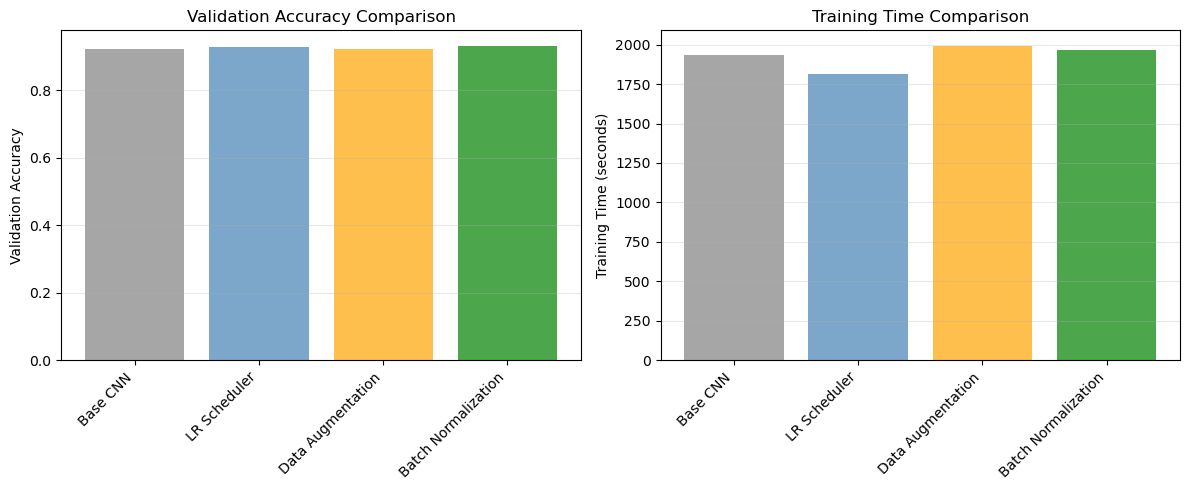

In [30]:
methods = ['Base CNN', 'LR Scheduler', 'Data Augmentation', 'Batch Normalization']
best_val_accs = [
    max(base_history['val_acc']),
    max(sched_history['val_acc']),
    max(aug_history['val_acc']),
    max(bn_history['val_acc'])
]

models_dict = {
    'Base CNN': base_cnn,
    'LR Scheduler': model_sched,
    'Data Augmentation': model_aug,
    'Batch Normalization': model_bn
}

comparison_df = pd.DataFrame({
    'Method': methods,
    'Best Val Accuracy': best_val_accs,
    'Training Time (s)': [
        sum(base_history['epoch_time']),
        sum(sched_history['epoch_time']),
        sum(aug_history['epoch_time']),
        sum(bn_history['epoch_time'])
    ]
})

print(comparison_df.to_string(index=False))

best_method_idx = comparison_df['Best Val Accuracy'].idxmax()
best_method_name = comparison_df.loc[best_method_idx, 'Method']
best_cnn_model = models_dict[best_method_name]

print(f"\n✓ Best Method: {best_method_name}")
print(f"  Validation Accuracy: {comparison_df.loc[best_method_idx, 'Best Val Accuracy']:.4f}")

# Visualize comparison
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(methods, best_val_accs, color=['gray', 'steelblue', 'orange', 'green'], alpha=0.7)
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 2, 2)
plt.bar(methods, comparison_df['Training Time (s)'], 
        color=['gray', 'steelblue', 'orange', 'green'], alpha=0.7)
plt.ylabel('Training Time (seconds)')
plt.title('Training Time Comparison')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()

plt.show()

In [31]:
best_cnn_model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = best_cnn_model(images)
        probs = torch.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Calculate metrics
test_acc = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='weighted', zero_division=0
)

print(f"\nTest Set Results:")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1 Score: {f1:.4f}")


Test Set Results:
  Accuracy: 0.9263
  Precision: 0.9281
  Recall: 0.9263
  F1 Score: 0.9262


In [32]:
torch.save(best_cnn_model.state_dict(), "a2_part3_weights_best.pkl")
print("\n✓ Model weights saved to: a2_part3_weights_best.pkl")

print("\n" + "="*80)
print("PART 3 COMPLETE!")
print("="*80)
print(f"Final Test Accuracy: {test_acc:.4f}")


✓ Model weights saved to: a2_part3_weights_best.pkl

PART 3 COMPLETE!
Final Test Accuracy: 0.9263
